In [ ]:
!pip install streamlit plotly seaborn matplotlib

In [ ]:
# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]
!pip install -q --upgrade kagglehub

In [ ]:

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "athlete_events.csv"

# Load the latest version
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "heesoo37/120-years-of-olympic-history-athletes-and-results",
    "athlete_events.csv"
)
'''
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "heesoo37/120-years-of-olympic-history-athletes-and-results",
  file_path
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
'''

print("First 5 records:", df.head())

Using Colab cache for faster access to the '120-years-of-olympic-history-athletes-and-results' dataset.
First 5 records:    ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1   2                  A Lamusi   M  23.0   170.0    60.0           China   
2   3       Gunnar Nielsen Aaby   M  24.0     NaN     NaN         Denmark   
3   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  Denmark/Sweden   
4   5  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands   

   NOC        Games  Year  Season       City          Sport  \
0  CHN  1992 Summer  1992  Summer  Barcelona     Basketball   
1  CHN  2012 Summer  2012  Summer     London           Judo   
2  DEN  1920 Summer  1920  Summer  Antwerpen       Football   
3  DEN  1900 Summer  1900  Summer      Paris     Tug-Of-War   
4  NED  1988 Winter  1988  Winter    Calgary  Speed Skating   

                              Event M

In [ ]:
%%writefile app.py

# OLYMPICS DATA ANALYSIS DASHBOARD

import streamlit as st
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.figure_factory as ff

import kagglehub
from kagglehub import KaggleDatasetAdapter
import preprocessor, helper

# LOAD DATASETS IN-MEMORY

@st.cache_data
def load_data():
    # Load athlete dataset
    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "heesoo37/120-years-of-olympic-history-athletes-and-results",
        "athlete_events.csv"
    )

    # Load NOC region dataset
    region_df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "heesoo37/120-years-of-olympic-history-athletes-and-results",
        "noc_regions.csv"
    )

    # Preprocess
    df_clean = preprocessor.preprocess(df, region_df)
    return df_clean

df = load_data()

# SIDEBAR
st.sidebar.title("🏅 Olympics Analysis Dashboard")
st.sidebar.image(
    'https://e7.pngegg.com/pngimages/1020/402/png-clipart-2024-summer-olympics-brand-circle-area-olympic-rings-olympics-logo-text-sport.png'
)

user_menu = st.sidebar.radio(
    'Select an Option',
    ('Medal Tally', 'Overall Analysis', 'Country-wise Analysis', 'Athlete wise Analysis')
)


# 1️⃣ MEDAL TALLY SECTION

if user_menu == 'Medal Tally':
    st.sidebar.header("Medal Tally Filters")
    years, country = helper.country_year_list(df)
    selected_year = st.sidebar.selectbox("Select Year", years)
    selected_country = st.sidebar.selectbox("Select Country", country)

    medal_tally = helper.fetch_medal_tally(df, selected_year, selected_country)

    # Dynamic title
    if selected_year == 'Overall' and selected_country == 'Overall':
        st.title("🏆 Overall Medal Tally")
    elif selected_year != 'Overall' and selected_country == 'Overall':
        st.title(f"🏆 Medal Tally - {selected_year}")
    elif selected_year == 'Overall' and selected_country != 'Overall':
        st.title(f"🏆 {selected_country} Overall Performance")
    else:
        st.title(f"🏆 {selected_country} in {selected_year}")

    st.table(medal_tally)


# 2️⃣ OVERALL ANALYSIS

elif user_menu == 'Overall Analysis':
    editions = df['Year'].nunique()
    cities = df['City'].nunique()
    sports = df['Sport'].nunique()
    events = df['Event'].nunique()
    athletes = df['Name'].nunique()
    nations = df['region'].nunique()

    st.title("📊 Top Statistics")
    col1, col2, col3 = st.columns(3)
    col1.metric("Editions", editions)
    col2.metric("Hosts", cities)
    col3.metric("Sports", sports)
    col1, col2, col3 = st.columns(3)
    col1.metric("Events", events)
    col2.metric("Nations", nations)
    col3.metric("Athletes", athletes)

    # Nations over time
    nations_over_time = helper.data_over_time(df, 'region')
    fig = px.line(nations_over_time, x="Edition", y="region")
    st.title("🌍 Participating Nations Over Time")
    st.plotly_chart(fig)

    # Events over time
    events_over_time = helper.data_over_time(df, 'Event')
    fig = px.line(events_over_time, x="Edition", y="Event")
    st.title("🎯 Events Over Time")
    st.plotly_chart(fig)

    # Athletes over time
    athlete_over_time = helper.data_over_time(df, 'Name')
    fig = px.line(athlete_over_time, x="Edition", y="Name")
    st.title("👥 Athletes Over Time")
    st.plotly_chart(fig)

    # Heatmap Sport vs Year
    st.title("🔥 Number of Events (Sport vs Year)")
    fig, ax = plt.subplots(figsize=(20, 20))
    x = df.drop_duplicates(['Year', 'Sport', 'Event'])
    heatmap_data = x.pivot_table(
        index='Sport',
        columns='Year',
        values='Event',
        aggfunc='count'
    ).fillna(0)
    sns.heatmap(heatmap_data, annot=True)
    st.pyplot(fig)

    # Most Successful Athletes
    st.title("🏅 Most Successful Athletes")
    sport_list = df['Sport'].unique().tolist()
    sport_list.sort()
    sport_list.insert(0, 'Overall')
    selected_sport = st.selectbox('Select a Sport', sport_list)
    x = helper.most_successful(df, selected_sport)
    st.table(x)


# 3️⃣ COUNTRY-WISE ANALYSIS

elif user_menu == 'Country-wise Analysis':
    st.sidebar.title('Country Filters')
    country_list = df['region'].dropna().unique().tolist()
    country_list.sort()
    selected_country = st.sidebar.selectbox('Select a Country', country_list)

    country_df = helper.yearwise_medal_tally(df, selected_country)
    fig = px.line(country_df, x="Year", y="Medal")
    st.title(f"📈 {selected_country} Medal Tally Over Years")
    st.plotly_chart(fig)

    st.title(f"🔥 {selected_country} Performance by Sport")
    pt = helper.country_event_heatmap(df, selected_country)
    fig, ax = plt.subplots(figsize=(20, 20))
    sns.heatmap(pt, annot=True)
    st.pyplot(fig)

    st.title(f"🏅 Top 10 Athletes of {selected_country}")
    top10_df = helper.most_successful_countrywise(df, selected_country)
    st.table(top10_df)


# 4️⃣ ATHLETE-WISE ANALYSIS

elif user_menu == 'Athlete wise Analysis':
    athlete_df = df.drop_duplicates(subset=['Name', 'region'])

    # Age distribution
    x1 = athlete_df['Age'].dropna()
    x2 = athlete_df[athlete_df['Medal'] == 'Gold']['Age'].dropna()
    x3 = athlete_df[athlete_df['Medal'] == 'Silver']['Age'].dropna()
    x4 = athlete_df[athlete_df['Medal'] == 'Bronze']['Age'].dropna()

    fig = ff.create_distplot(
        [x1, x2, x3, x4],
        ['Overall Age', 'Gold', 'Silver', 'Bronze'],
        show_hist=False,
        show_rug=False
    )
    fig.update_layout(width=1000, height=600)
    st.title("📊 Age Distribution of Athletes")
    st.plotly_chart(fig)

    # Height vs Weight
    st.title("⚖ Height vs Weight")
    sport_list = df['Sport'].unique().tolist()
    sport_list.sort()
    sport_list.insert(0, 'Overall')
    selected_sport = st.selectbox('Select Sport', sport_list)
    temp_df = helper.weight_v_height(df, selected_sport)

    fig, ax = plt.subplots()
    sns.scatterplot(
        data=temp_df,
        x='Weight',
        y='Height',
        hue='Medal',
        style='Sex',
        s=60
    )
    st.pyplot(fig)

    # Men vs Women
    st.title("👨‍👩‍👧‍👦 Men vs Women Participation")
    final = helper.men_vs_women(df)
    fig = px.line(final, x="Year", y=["Male", "Female"])
    fig.update_layout(width=1000, height=600)
    st.plotly_chart(fig)



Overwriting app.py


In [ ]:
%%writefile preprocessor.py

import pandas as pd

def preprocess(df, region_df):

    # 1. Keep only Summer Olympics data
    df = df[df['Season'] == 'Summer']

    # 2. Merge NOC region data to get country names
    df = df.merge(region_df, on='NOC', how='left')

    # 3. Remove duplicate rows
    df.drop_duplicates(inplace=True)

    # 4. Convert Medal column into dummy variables (Gold, Silver, Bronze)
    df = pd.concat([df, pd.get_dummies(df['Medal'])], axis=1)

    return df


Overwriting preprocessor.py


In [ ]:
%%writefile helper.py

import numpy as np


# 1️⃣ FETCH MEDAL TALLY
# Returns a medal tally table based on year and country selection

def fetch_medal_tally(df, year, country):

    # Remove duplicate medals (unique per Team, Event, Year)
    medal_df = df.drop_duplicates(
        subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal']
    )

    flag = 0  # Used to handle country-only filter

    # 1. Overall Year & Overall Country
    if year == 'Overall' and country == 'Overall':
        temp_df = medal_df

    # 2. Overall Year & Specific Country
    if year == 'Overall' and country != 'Overall':
        flag = 1
        temp_df = medal_df[medal_df['region'] == country]

    # 3. Specific Year & Overall Country
    if year != 'Overall' and country == 'Overall':
        temp_df = medal_df[medal_df['Year'] == int(year)]

    # 4. Specific Year & Specific Country
    if year != 'Overall' and country != 'Overall':
        temp_df = medal_df[
            (medal_df['Year'] == int(year)) & (medal_df['region'] == country)
        ]

    # Grouping data depending on the filter
    if flag == 1:
        # Country over years
        x = temp_df.groupby('Year').sum()[['Gold', 'Silver', 'Bronze']].sort_values('Year').reset_index()
    else:
        # Medal tally by region
        x = temp_df.groupby('region').sum()[['Gold', 'Silver', 'Bronze']].sort_values('Gold', ascending=False).reset_index()

    # Total medals column
    x['total'] = x['Gold'] + x['Silver'] + x['Bronze']

    # Convert all columns to integer
    x['Gold'] = x['Gold'].astype('int')
    x['Silver'] = x['Silver'].astype('int')
    x['Bronze'] = x['Bronze'].astype('int')
    x['total'] = x['total'].astype('int')

    return x



# 2️⃣ DROPDOWN OPTIONS: YEARS & COUNTRIES
# Returns sorted lists for sidebar dropdowns

def country_year_list(df):

    # Years list
    years = df['Year'].unique().tolist()
    years.sort()
    years.insert(0, 'Overall')  # Add 'Overall' option

    # Countries list
    country = np.unique(df['region'].dropna().values).tolist()
    country.sort()
    country.insert(0, 'Overall')  # Add 'Overall' option

    return years, country



# 3️⃣ DATA OVER TIME
# Returns data for line plots showing trends over years
# col = column name (e.g., 'region', 'Event', 'Name')

def data_over_time(df, col):

    # Count unique entries per year
    nations_over_time = df.drop_duplicates(['Year', col])['Year'].value_counts().reset_index().sort_values('index')

    # Rename columns for plotting
    nations_over_time.rename(columns={'index': 'Edition', 'Year': col}, inplace=True)

    return nations_over_time



# 4️⃣ MOST SUCCESSFUL ATHLETES
# Returns top 15 athletes for a sport or overall

def most_successful(df, sport):

    temp_df = df.dropna(subset=['Medal'])  # Only athletes who won medals

    # Filter by sport if not overall
    if sport != 'Overall':
        temp_df = temp_df[temp_df['Sport'] == sport]

    # Count medals and merge to get Sport & Country
    x = temp_df['Name'].value_counts().reset_index().head(15).merge(
        df, left_on='index', right_on='Name', how='left'
    )[['index', 'Name_x', 'Sport', 'region']].drop_duplicates('index')

    x.rename(columns={'index': 'Name', 'Name_x': 'Medals'}, inplace=True)

    return x



# 5️⃣ YEARWISE MEDAL TALLY FOR COUNTRY
# Returns medal counts for a country across years

def yearwise_medal_tally(df, country):

    temp_df = df.dropna(subset=['Medal'])

    temp_df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'], inplace=True)

    new_df = temp_df[temp_df['region'] == country]

    final_df = new_df.groupby('Year').count()['Medal'].reset_index()

    return final_df



# 6️⃣ COUNTRY EVENT HEATMAP
# Returns pivot table of Sports vs Years for a country

def country_event_heatmap(df, country):

    temp_df = df.dropna(subset=['Medal'])

    temp_df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'], inplace=True)

    new_df = temp_df[temp_df['region'] == country]

    pt = new_df.pivot_table(index='Sport', columns='Year', values='Medal', aggfunc='count').fillna(0)

    return pt



# 7️⃣ MOST SUCCESSFUL COUNTRYWISE
# Returns top 10 athletes from a specific country

def most_successful_countrywise(df, country):

    temp_df = df.dropna(subset=['Medal'])

    temp_df = temp_df[temp_df['region'] == country]

    x = temp_df['Name'].value_counts().reset_index().head(10).merge(
        df, left_on='index', right_on='Name', how='left'
    )[['index', 'Name_x', 'Sport']].drop_duplicates('index')

    x.rename(columns={'index': 'Name', 'Name_x': 'Medals'}, inplace=True)

    return x



# 8️⃣ HEIGHT VS WEIGHT DATA
# Returns athlete data for scatter plot

def weight_v_height(df, sport):

    athlete_df = df.drop_duplicates(subset=['Name', 'region'])

    athlete_df['Medal'].fillna('No Medal', inplace=True)

    if sport != 'Overall':
        temp_df = athlete_df[athlete_df['Sport'] == sport]
        return temp_df
    else:
        return athlete_df



# 9️⃣ MEN VS WOMEN PARTICIPATION
# Returns yearly counts of male and female athletes

def men_vs_women(df):

    athlete_df = df.drop_duplicates(subset=['Name', 'region'])

    men = athlete_df[athlete_df['Sex'] == 'M'].groupby('Year').count()['Name'].reset_index()
    women = athlete_df[athlete_df['Sex'] == 'F'].groupby('Year').count()['Name'].reset_index()

    final = men.merge(women, on='Year', how='left')
    final.rename(columns={'Name_x': 'Male', 'Name_y': 'Female'}, inplace=True)

    final.fillna(0, inplace=True)

    return final


Overwriting helper.py


In [ ]:
%%writefile requirements.txt

streamlit
plotly
seaborn
matplotlib
pyngrok
pymupdf


Overwriting requirements.txt


In [ ]:
# Install dependencies
!pip install -q streamlit pyngrok

In [ ]:
!pkill ngrok


In [13]:

import time
from pyngrok import ngrok
import subprocess

# Set your ngrok authentication token

import time
import subprocess
from pyngrok import ngrok

# Force completely fresh start
ngrok.kill()

# Set your ngrok authentication token
ngrok.set_auth_token("38ZlpVDp2Q2GAEwYhaQh3OxDEne_65yrLDHuz5s4hrqT3Hgmi")

# Start Streamlit
process = subprocess.Popen(
    [
        "streamlit", "run", "app.py",
        "--server.port", "8521",
        "--server.headless", "true",
        "--server.enableCORS", "false",
        "--server.enableXsrfProtection", "false"
    ]
)

time.sleep(5)

# Make sure no tunnels exist
for tunnel in ngrok.get_tunnels():
    ngrok.disconnect(tunnel.public_url)

# Create NEW tunnel (no custom domain)
public_url = ngrok.connect(addr=8521, bind_tls=True)

print("🚀 Streamlit URL:", public_url.public_url)



🚀 Streamlit URL: https://unchided-nondetractory-stefani.ngrok-free.dev


In [14]:
!pip install -q pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 50.8 MB/s eta 0:00:00


Saving 23102B0005 ML SDP E6.pdf to 23102B0005 ML SDP E6.pdf
Total pages: 1
--- Page 1 ---


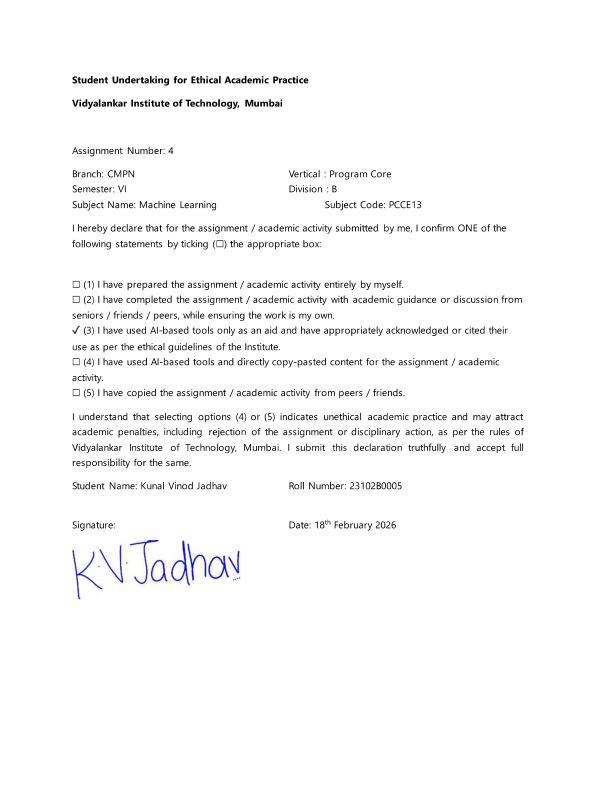

In [15]:

from google.colab import files
import fitz
from IPython.display import display, Image

# Step 1: Upload PDF
uploaded = files.upload()
pdf_file = list(uploaded.keys())[0]

# Step 2: Open PDF
pdf = fitz.open(pdf_file)
print("Total pages:", len(pdf))

# Step 3: Convert each page to image and display
for page_num, page in enumerate(pdf, start=1):
    print(f"--- Page {page_num} ---")
    pix = page.get_pixmap()
    img_bytes = pix.tobytes("png")
    display(Image(data=img_bytes))
